
# Predicción de Bitcoin (BTC) con Arquitecturas Avanzadas 🚀₿

En este notebook cambiamos de un caso “productivo” (café) a un activo **altamente volátil**: **Bitcoin (BTC-USD)**.

La meta NO es prometer “el santo grial del trading”. El objetivo es didáctico:

- ver cómo preparar una serie financiera,
- entrenar una arquitectura recurrente más potente (BiLSTM + Dropout),
- y entender **por qué LSTM puede ayudar** en presencia de **no linealidad**, **regímenes**, y **patrones temporales**.

> Aviso responsable: un modelo que predice bien en una partición temporal no implica que sea rentable al operar (hay costos, slippage, y cambios de régimen). Este notebook es para aprendizaje de modelado secuencial.



## 1. Contexto: ¿por qué BTC es un “stress test” para RNNs?

Bitcoin tiene características que complican el pronóstico:

- **Volatilidad alta**: cambios abruptos y colas pesadas.
- **No estacionariedad**: el “comportamiento típico” cambia con el tiempo (bull/bear markets).
- **Regímenes**: periodos con dinámicas distintas (euforia, pánico, lateralidad).
- **Ruido**: gran parte del movimiento diario puede parecer aleatorio a corta escala.

Aun así, las redes LSTM se usan porque pueden:

- capturar **dependencias temporales no lineales**,
- aprender **representaciones internas** (memoria) que resumen el pasado,
- manejar mejor el problema de **gradiente desvaneciente** frente a RNN simples.



## 2. Sobre el “mito” de TensorFlow Hub en Finanzas

Es común preguntar: “¿No puedo descargar un modelo pre-entrenado que ya sepa predecir precios?”

En visión y NLP es común porque las imágenes y el lenguaje comparten estructuras generales.

En finanzas, **cada mercado es un universo**:

- cambian reglas y microestructura,
- hay shocks exógenos,
- y el patrón histórico puede romperse.

Por eso, en práctica se construyen modelos **entrenados en el activo específico** y se reentrenan.



## 3. Obtención de datos: Yahoo Finance (yfinance)

Usaremos `yfinance` para descargar BTC-USD diario desde 2015.

### 📁 Recomendación Jupyter Book (modo offline)

Cuando construyes el Jupyter Book (por ejemplo en CI), puede no haber acceso a internet.

Por eso el notebook:

1) intenta descargar desde Yahoo Finance;
2) si falla, intenta cargar un archivo cacheado en:

- `data/BTC-USD.csv` (recomendado)

Estructura sugerida del repo:

```
my-book/
  content/
    rnn/
      05_btc_bilstm.ipynb
  data/
    Exportaciones.xlsx
    BTC-USD.csv
```


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Reproducibility (best-effort)
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)


In [2]:

# -----------------------------------------
# Data acquisition with offline fallback
# -----------------------------------------
DATA_CSV_CANDIDATES = [
    Path("data/BTC-USD.csv"),
    Path("../data/BTC-USD.csv"),
    Path("../../data/BTC-USD.csv"),
    Path("BTC-USD.csv"),
]

def try_load_cached_csv() -> pd.DataFrame | None:
    for p in DATA_CSV_CANDIDATES:
        if p.exists():
            df = pd.read_csv(p, parse_dates=["Date"])
            df = df.set_index("Date").sort_index()
            print(f"✅ Loaded cached BTC data from: {p.resolve()}")
            return df
    return None

df_btc = None

try:
    import yfinance as yf  # pip install yfinance

    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d", auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Empty download from yfinance.")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Downloaded BTC-USD from Yahoo Finance. Rows: {len(df_btc)}")

    # Save cache (best-effort) if running in a writable environment
    out_cache = Path("data/BTC-USD.csv")
    try:
        out_cache.parent.mkdir(parents=True, exist_ok=True)
        df_btc.reset_index().to_csv(out_cache, index=False)
        print(f"💾 Cached data saved to: {out_cache.resolve()}")
    except Exception as e:
        print(f"⚠️ Could not write cache file (ok in read-only builds): {e}")

except Exception as e:
    print(f"⚠️ yfinance download failed: {e}")
    df_btc = try_load_cached_csv()

if df_btc is None:
    raise FileNotFoundError(
        "Could not obtain BTC data. "
        "Install yfinance and ensure internet access, OR place a cached file at data/BTC-USD.csv."
    )

# We will use the Close price
if "Close" not in df_btc.columns:
    raise ValueError(f"Expected 'Close' column. Found: {list(df_btc.columns)}")

close = df_btc[["Close"]].dropna().astype(float)
print("Date range:", close.index.min().date(), "→", close.index.max().date())
display(close.head())


✅ Downloaded BTC-USD from Yahoo Finance. Rows: 4063
💾 Cached data saved to: D:\Documentos\RNN Manual\contenidos\data\BTC-USD.csv
Date range: 2015-01-01 → 2026-02-14


Price,Close
Ticker,BTC-USD
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999


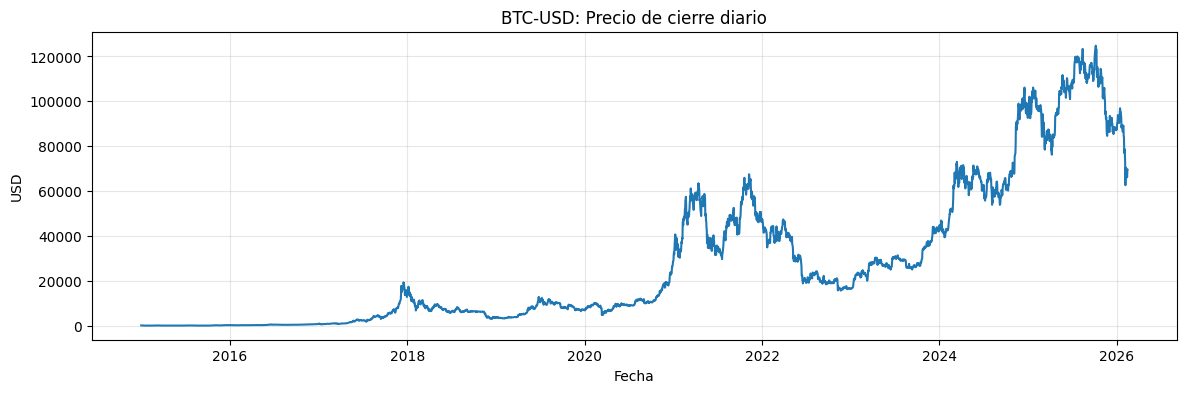

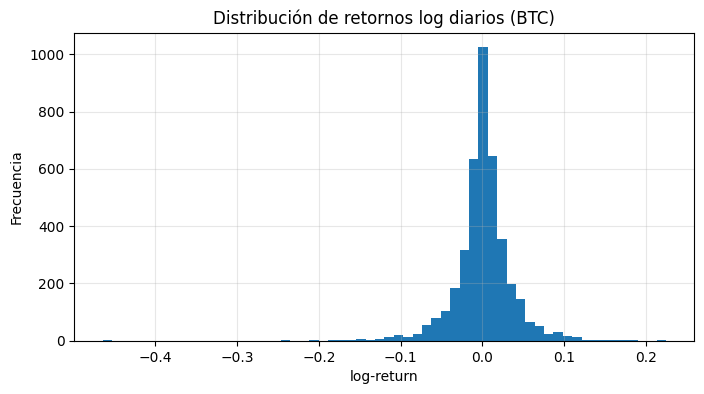

In [3]:

plt.figure(figsize=(14, 4))
plt.plot(close.index, close["Close"].values)
plt.title("BTC-USD: Precio de cierre diario")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.show()

# Volatility hint: daily log-returns distribution
log_returns = np.log(close["Close"]).diff().dropna()
plt.figure(figsize=(8, 4))
plt.hist(log_returns.values, bins=60)
plt.title("Distribución de retornos log diarios (BTC)")
plt.xlabel("log-return")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()



## 4. Formulación del problema: ventanas temporales

Usaremos una ventana de `LOOK_BACK=60` días (≈ 2 meses) para predecir el **precio de cierre del día siguiente**.

- **X:** últimos 60 cierres (escalados)
- **y:** cierre de mañana (escalado)

> Nota: En finanzas a menudo se predicen **retornos** (más estacionarios) en lugar de precios. Aquí empezamos con precios por simplicidad, pero al final te dejo un reto para cambiar a retornos.


In [4]:

from sklearn.preprocessing import MinMaxScaler

# Convert to numpy
data = close.values  # shape (T, 1)

# Train/Test split (time-based): 90% / 10%
LOOK_BACK = 60

# We split BEFORE scaling to avoid leakage
split_idx = int(len(data) * 0.90)
train_raw = data[:split_idx]
test_raw = data[split_idx:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

def make_windows(series_2d: np.ndarray, look_back: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Build supervised windows from a univariate series (T, 1).

    Returns:
        X: (N, look_back, 1)
        y: (N, 1)
    """
    X_list, y_list = [], []
    for i in range(look_back, len(series_2d)):
        X_list.append(series_2d[i - look_back : i, 0])
        y_list.append(series_2d[i, 0])
    X = np.array(X_list, dtype=float).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=float).reshape(-1, 1)
    return X, y

X_train, y_train = make_windows(train_scaled, LOOK_BACK)
X_test, y_test = make_windows(test_scaled, LOOK_BACK)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)


X_train: (3596, 60, 1) y_train: (3596, 1)
X_test : (347, 60, 1) y_test : (347, 1)



## 5. Baseline rápido: “mañana = hoy”

Antes de deep learning, comparemos contra un baseline ingenuo:

- predicción = último valor observado en la ventana

Si el modelo no supera esto, no está aportando mucho.


In [5]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Baseline: predict y_t as the last value in the window (scaled)
baseline_pred_scaled = X_test[:, -1, 0].reshape(-1, 1)

# Back to real prices
y_test_real = scaler.inverse_transform(y_test)
baseline_pred_real = scaler.inverse_transform(baseline_pred_scaled)

def rmse(y_true: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

baseline_rmse = rmse(y_test_real, baseline_pred_real)
baseline_mae = float(mean_absolute_error(y_test_real, baseline_pred_real))

print(f"Baseline (tomorrow=today) | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")


Baseline (tomorrow=today) | RMSE: 2138.20 | MAE: 1545.96



## 6. Arquitectura: Bidirectional LSTM + Dropout

### ¿Por qué Bidirectional?

Una BiLSTM procesa la secuencia:

- hacia adelante (del pasado al presente)
- y hacia atrás (del presente al pasado)

**Ojo importante (forecasting):**  
No estamos usando “datos del futuro”. Dentro de cada ventana, solo hay datos del pasado. La bidireccionalidad solo ayuda a extraer *relaciones internas* dentro de esa ventana.

### ¿Por qué Dropout?

Reduce overfitting “apagando” aleatoriamente neuronas durante el entrenamiento.


In [6]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 60, 100)           20800     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 60, 100)           0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 100)               60400     
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense (Dense)               (None, 25)                2525      
                                                                 
 dense_1 (Dense)             (None, 1)                


## 7. Entrenamiento

Entrenaremos con validación temporal (el 10% final).


Epoch 1/25

113/113 [==============================] - 11s 43ms/step - loss: 0.0049 - val_loss: 0.0048 - lr: 0.0010
Epoch 2/25
113/113 [==============================] - 3s 30ms/step - loss: 0.0011 - val_loss: 0.0050 - lr: 0.0010
Epoch 3/25
113/113 [==============================] - 3s 30ms/step - loss: 0.0010 - val_loss: 0.0027 - lr: 0.0010
Epoch 4/25
113/113 [==============================] - 4s 31ms/step - loss: 8.1868e-04 - val_loss: 0.0014 - lr: 0.0010
Epoch 5/25
113/113 [==============================] - 3s 30ms/step - loss: 6.7042e-04 - val_loss: 0.0011 - lr: 0.0010
Epoch 6/25
113/113 [==============================] - 4s 32ms/step - loss: 7.2729e-04 - val_loss: 0.0038 - lr: 0.0010
Epoch 7/25
113/113 [==============================] - 4s 32ms/step - loss: 6.1529e-04 - val_loss: 0.0126 - lr: 0.0010
Epoch 8/25
113/113 [==============================] - 3s 30ms/step - loss: 5.9900e-04 - val_loss: 0.0034 - lr: 0.0010
Epoch 9/25
113/113 [==============================] - 3s 31ms/step

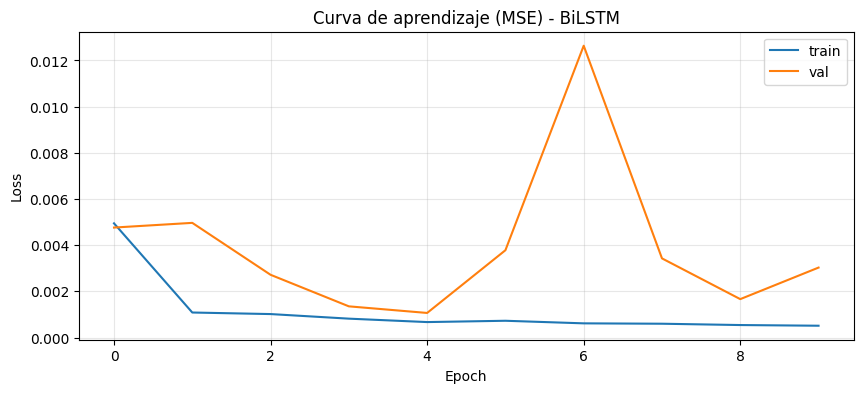

In [7]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Curva de aprendizaje (MSE) - BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 8. Evaluación y visualización (precio real)

Calculamos RMSE/MAE en la escala real (USD) y comparamos con el baseline.


In [8]:

pred_scaled = model.predict(X_test, verbose=0)

pred_real = scaler.inverse_transform(pred_scaled)
y_test_real = scaler.inverse_transform(y_test)

model_rmse = rmse(y_test_real, pred_real)
model_mae = float(mean_absolute_error(y_test_real, pred_real))

print(f"BiLSTM | RMSE: {model_rmse:.2f} | MAE: {model_mae:.2f}")
print(f"Baseline | RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f}")


BiLSTM | RMSE: 3458.93 | MAE: 2629.55
Baseline | RMSE: 2138.20 | MAE: 1545.96


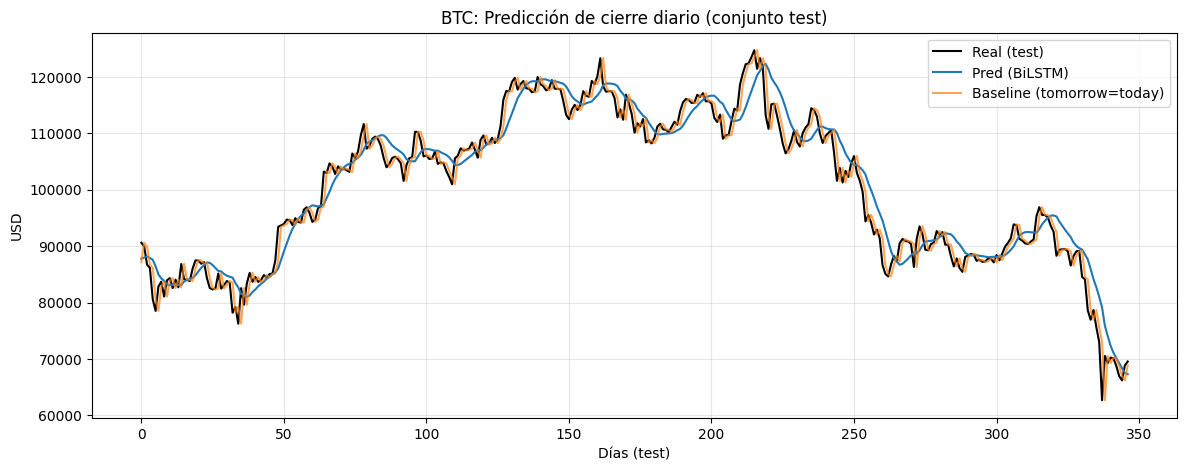

In [9]:

plt.figure(figsize=(14, 5))
plt.plot(y_test_real, color="black", label="Real (test)")
plt.plot(pred_real, label="Pred (BiLSTM)")
plt.plot(baseline_pred_real, label="Baseline (tomorrow=today)", alpha=0.7)
plt.title("BTC: Predicción de cierre diario (conjunto test)")
plt.xlabel("Días (test)")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 9. Interpretación honesta

- Si tu predicción parece “un paso atrás”, es muy común: el baseline “mañana = hoy” ya es fuerte en precios.
- En BTC, cambios de régimen pueden romper patrones aprendidos.
- A veces el modelo mejora *métricas* pero visualmente sigue “suavizando” picos.

📌 Lo valioso didácticamente es ver:

- cómo se evita leakage (split temporal + scaler en train),
- cómo comparar contra un baseline,
- cómo arquitecturas con memoria pueden capturar estructura **dentro de una ventana**.



## 10. Guardar el modelo (tu “pre-entrenado”)

Si quieres reutilizarlo sin reentrenar, guarda el modelo y el scaler.

> Para un curso, recomiendo guardar el modelo y **documentar** la fecha de entrenamiento + rango de datos.


In [10]:

# Save Keras model
model_out = Path("models/btc_bilstm.keras")
try:
    model_out.parent.mkdir(parents=True, exist_ok=True)
    model.save(model_out)
    print(f"✅ Model saved to: {model_out.resolve()}")
except Exception as e:
    print(f"⚠️ Could not save model (ok in read-only builds): {e}")


✅ Model saved to: D:\Documentos\RNN Manual\contenidos\models\btc_bilstm.keras



## 11. Reto final (más realista en finanzas)

En lugar de predecir el **precio**, prueba predecir el **retorno**:

\[ r_t = \log(P_t) - \log(P_{t-1}) \]

¿Por qué? Los retornos suelen ser más estacionarios que el precio.

Tareas:

1) Construye la serie de retornos log.  
2) Repite el pipeline (ventanas, split temporal).  
3) Predice retorno y reconstruye el precio acumulando retornos.
